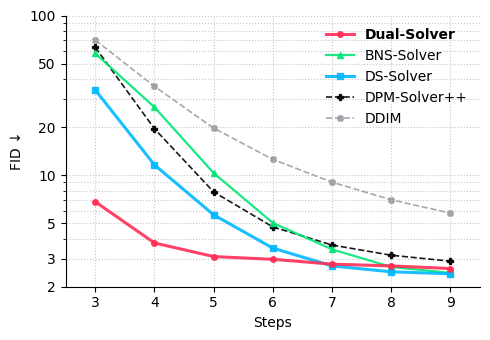

In [4]:
# Apply: DPM-Solver++ = black, Euler = gray. Others unchanged (neon).
# Dual (ours) bold; DS/BNS medium; DPM/Euler dashed.

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import numpy as np

steps = np.array([3, 4, 5, 6, 7, 8, 9])
results = {
    "Dual-Solver":    np.array([ 6.81,  3.76,  3.09,  2.97,  2.77, 2.70, 2.60]),
    "BNS-Solver":     np.array([57.88, 26.64, 10.31,  5.02,  3.43, 2.66, 2.44]),
    "DS-Solver":      np.array([34.15, 11.60,  5.64,  3.49,  2.70, 2.48, 2.41]),
    "DPM-Solver++":   np.array([63.24, 19.53,  7.85,  4.74,  3.65, 3.15, 2.89]),
    "DDIM":          np.array([70.15, 35.98, 19.70, 12.55,  9.03, 7.01, 5.78]),
    
}

style = {
    "Dual-Solver": dict(color="#FF2D55", lw=2.2, ls="-",  marker="o", zorder=5),
    "DS-Solver": dict(color="#00B8FF", lw=2.2, ls="-",  marker="s", zorder=4),
    "BNS-Solver":      dict(color="#00E676", lw=1.6, ls="-",  marker="^", zorder=3),
    "DPM-Solver++":   dict(color="#000000", lw=1.2, ls="--", marker="P", zorder=2),  # black
    "DDIM":          dict(color="#9AA0A6", lw=1.2, ls="--", marker="X", zorder=1),  # gray
}

fig, ax = plt.subplots(figsize=(5, 3.5))
lines = {}

for label, vals in results.items():
    st = style[label]
    (line,) = ax.plot(
        steps, vals,
        label=label, marker=st["marker"], linewidth=st["lw"],
        linestyle=st["ls"], color=st["color"], markersize=4, zorder=st["zorder"], alpha=0.9
    )
    lines[label] = line

ax.set_xlabel("Steps")
ax.set_ylabel("FID ↓")
ax.set_xticks(steps)
ax.set_xlim(2.5, 9.5)
ax.set_yscale("log")
yticks = [2, 3, 5, 10, 20, 50, 100]
ax.set_yticks(yticks)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _ : f"{y:g}"))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.grid(True, which="both", linestyle=":", linewidth=0.8, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(handles=[lines[k] for k in results.keys()], frameon=False, loc="upper right")
for txt in leg.get_texts():
    if txt.get_text().startswith("Dual-Solver"):
        txt.set_fontweight("bold")

fig.tight_layout()
plt.show()
